# Stage 2 — Generating 2D Navier-Stokes data

This notebook builds the training data for our first neural operator experiment, reproducing the setup of Section 7.3 of the paper (*Kovachki, Li et al., "Neural Operator: Learning Maps Between Function Spaces"*).

### The operator learning problem

We work with the 2D incompressible Navier-Stokes equation in **vorticity-streamfunction form** on the periodic torus $D=[0,1)^2$:

$$\frac{\partial w}{\partial t} + u\cdot\nabla w = \nu \Delta w + f, \qquad -\Delta \psi = w, \qquad u = (\partial_y \psi, -\partial_x \psi)$$

where $w$ is vorticity, $u$ is the (divergence-free) velocity field recovered from the streamfunction $\psi$ via the Biot-Savart law, $\nu$ is viscosity, and $f$ is a fixed forcing function that continually injects energy so the flow reaches a statistically-steady turbulent regime.

The **operator** we want to learn is the solution map
$$G^\dagger : a \longmapsto u\big|_{[0,T]}, \qquad a := w(\cdot, 0)$$
i.e. given an initial vorticity field $a$, predict the vorticity field at a later time (or a trajectory of later times). This is exactly the abstract setting of Section 2.1 of the paper: $\mathcal{A} \to \mathcal{U}$ mapping parameter functions (here, initial conditions) to solution functions.

We generate training data by:
1. Sampling many random initial vorticity fields $a^{(i)}$ from a Gaussian random field (GRF).
2. Solving the PDE forward in time with a pseudo-spectral solver to get $u^{(i)} = G^\dagger(a^{(i)})$.
3. Saving the $(a^{(i)}, u^{(i)})$ pairs to disk for the model notebooks (02-05) to train on.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt

from neural_operators.data.grf import GaussianRF2d
from neural_operators.data.navier_stokes_2d import solve_navier_stokes_2d, default_forcing

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## The Gaussian random field (GRF)

Following the paper, initial vorticity fields are drawn from
$$a \sim \mathcal{N}\left(0,\ 7^{3/2}(-\Delta + 49 I)^{-2.5}\right)$$
i.e. $\tau=7$, $\alpha=2.5$ in the general covariance operator $C = \sigma^2(-\Delta+\tau^2 I)^{-\alpha}$. Because $-\Delta$ is diagonalized by the Fourier basis on a periodic domain, sampling reduces to drawing independent complex Gaussian noise for each Fourier mode $k$, scaling it by $\sqrt{\text{eigenvalue}(k)}$, and inverse-FFT-ing back to physical space. Larger $\alpha$ (or $\tau$) means faster spectral decay, i.e. a **smoother** random field. This is implemented in `neural_operators/data/grf.py`.

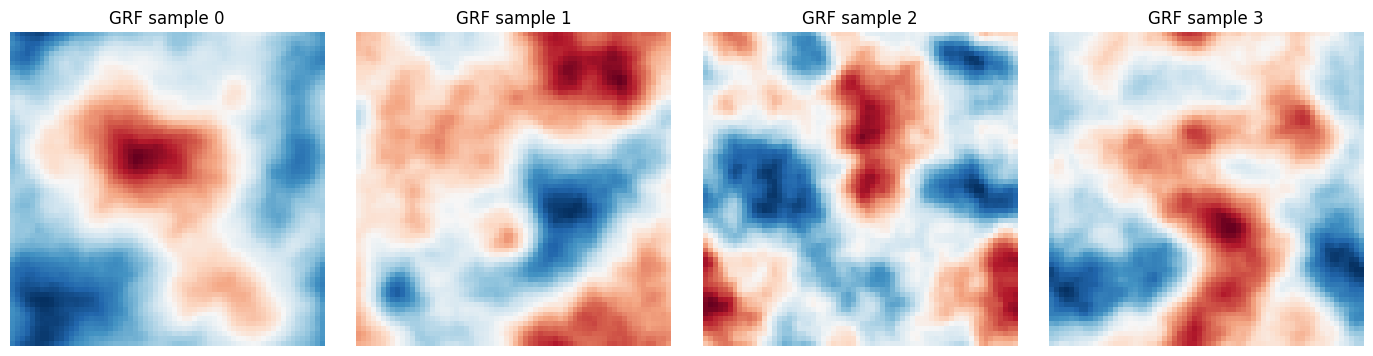

In [2]:
n = 64  # grid resolution (n x n), kept modest for fast iteration
grf = GaussianRF2d(n, alpha=2.5, tau=7.0, device=device)
samples = grf.sample(4)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for i, ax in enumerate(axes):
    im = ax.imshow(samples[i].cpu(), cmap="RdBu_r")
    ax.set_title(f"GRF sample {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## The pseudo-spectral Navier-Stokes solver

`solve_navier_stokes_2d` (in `neural_operators/data/navier_stokes_2d.py`) integrates the vorticity equation forward in time, following the method of Chandler & Kerswell (2013) cited in the paper. The key ideas:

- On a periodic domain, `-Delta` is diagonal in Fourier space, so the streamfunction is recovered from vorticity by simple division: $\hat\psi(k) = \hat w(k)/|k|^2$ (Biot-Savart law).
- All spatial derivatives ($\nabla w$, $u$) become multiplication by $ik$ in Fourier space, and are transformed back to physical space via inverse FFT to compute the nonlinear advection term $u\cdot\nabla w$ pointwise (a **pseudo-spectral** method).
- The viscous term $\nu\Delta w$ is stiff, so it is treated **implicitly** (Crank-Nicolson), while the nonlinear advection and forcing are treated **explicitly**. This lets us take much larger time steps than a fully-explicit scheme would allow.
- A 2/3-rule dealiasing mask removes the highest 1/3 of Fourier modes after computing the nonlinear term, preventing aliasing errors from corrupting the resolved modes.

We use viscosity $\nu = 10^{-3}$ first — a moderate value corresponding to Reynolds number around 20, which is the easiest case in the paper's benchmark (<1% relative error achieved by FNO).

snapshot times: [ 3.333  6.666  9.999 13.332 16.665 19.998]


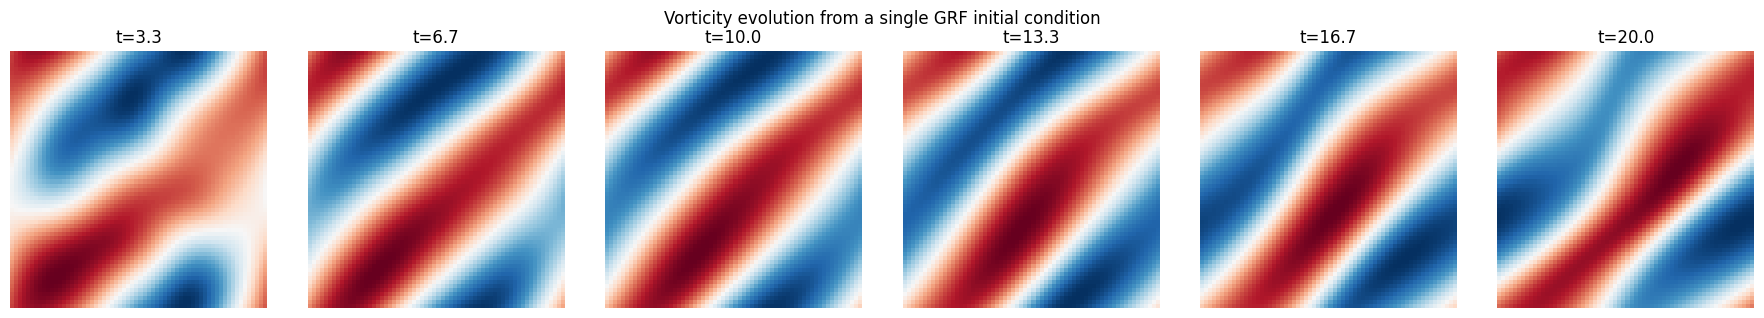

In [3]:
f = default_forcing(n, device=device)
w0 = grf.sample(1)

sol, sol_t = solve_navier_stokes_2d(w0, f, visc=1e-3, T=20.0, delta_t=1e-3, record_steps=6)
print("snapshot times:", sol_t.cpu().numpy())

fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
for i, ax in enumerate(axes):
    im = ax.imshow(sol[0, ..., i].cpu(), cmap="RdBu_r")
    ax.set_title(f"t={sol_t[i].item():.1f}")
    ax.axis("off")
plt.suptitle("Vorticity evolution from a single GRF initial condition")
plt.tight_layout()
plt.show()

We should see the initially smooth, large-scale GRF field roll up into finer vortical structures as it evolves — characteristic 2D turbulence behaviour (energy cascades to large scales / enstrophy to small scales), continually sustained by the forcing term.

## Building the training dataset

For the first operator-learning task we keep it simple: **learn the map from the vorticity field at $t=0$ (mildly evolved as a burn-in) to the vorticity field at a later time $T$**, i.e. a single-step flow map $a \mapsto u$, matching the paper's Section 7.3 setup. We generate `N_TRAIN + N_TEST` trajectories, each producing one input/output pair.

We keep the dataset modest (small N, small resolution) so the whole pipeline runs quickly; the `Notes / scope decisions` in the project plan describes how to scale this up later.

In [4]:
N_TRAIN = 200
N_TEST = 40
N_TOTAL = N_TRAIN + N_TEST
BATCH = 20

VISC = 1e-3
T_BURNIN = 4.5   # let the flow develop away from the raw GRF before recording "a"
T_PREDICT = 2.0  # a -> u is the map from t=T_BURNIN to t=T_BURNIN+T_PREDICT
DT = 1e-3

f = default_forcing(n, device=device)

a_list, u_list = [], []
for start in range(0, N_TOTAL, BATCH):
    bs = min(BATCH, N_TOTAL - start)
    w0 = grf.sample(bs)

    burnin, _ = solve_navier_stokes_2d(w0, f, VISC, T=T_BURNIN, delta_t=DT, record_steps=1)
    a = burnin[..., -1]

    traj, _ = solve_navier_stokes_2d(a, f, VISC, T=T_PREDICT, delta_t=DT, record_steps=1)
    u = traj[..., -1]

    a_list.append(a.cpu())
    u_list.append(u.cpu())
    print(f"generated {start + bs}/{N_TOTAL}")

a_data = torch.cat(a_list, dim=0)
u_data = torch.cat(u_list, dim=0)
print("a_data", a_data.shape, "u_data", u_data.shape)

generated 20/240


generated 40/240


generated 60/240


generated 80/240


generated 100/240


...

generated 160/240


generated 180/240


generated 200/240


generated 220/240


generated 240/240
a_data torch.Size([240, 64, 64]) u_data torch.Size([240, 64, 64])


In [5]:
os.makedirs("../data_cache", exist_ok=True)
torch.save(
    {"a": a_data, "u": u_data, "n": n, "visc": VISC, "n_train": N_TRAIN, "n_test": N_TEST},
    "../data_cache/navier_stokes_64.pt",
)
print("saved to ../data_cache/navier_stokes_64.pt")

saved to ../data_cache/navier_stokes_64.pt


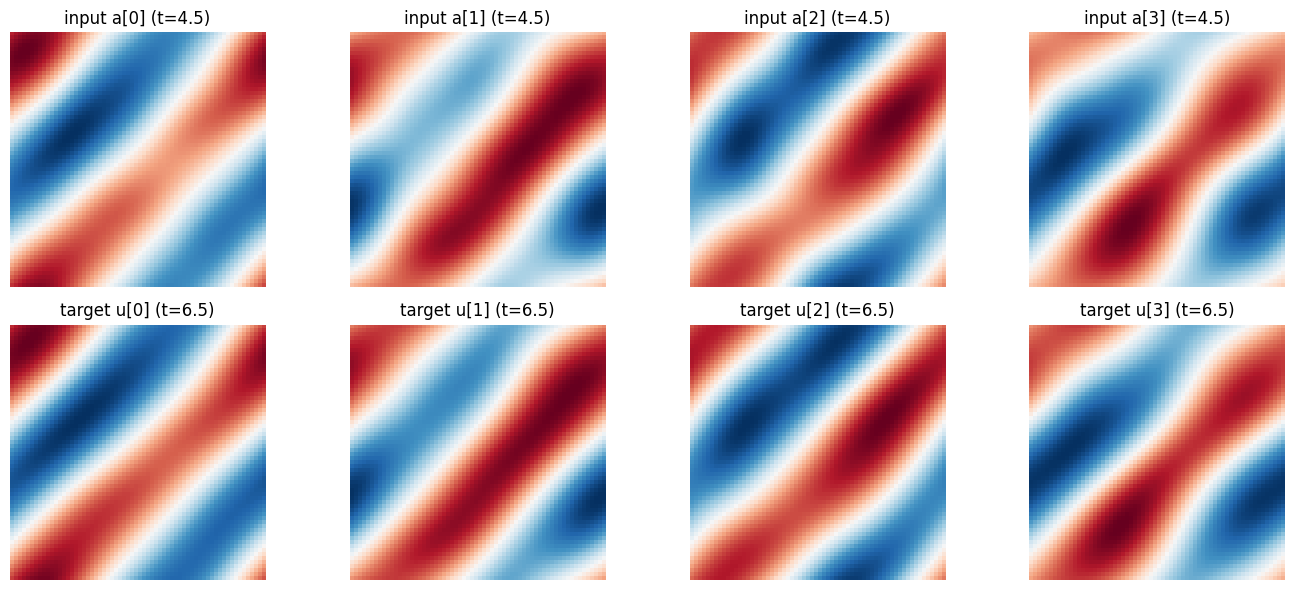

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    axes[0, i].imshow(a_data[i], cmap="RdBu_r")
    axes[0, i].set_title(f"input a[{i}] (t={T_BURNIN})")
    axes[0, i].axis("off")
    axes[1, i].imshow(u_data[i], cmap="RdBu_r")
    axes[1, i].set_title(f"target u[{i}] (t={T_BURNIN+T_PREDICT})")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## Next step

With `data_cache/navier_stokes_64.pt` in hand, `02_fno.ipynb` builds and trains the Fourier Neural Operator on this input/output map, and checks that it is **discretization-invariant** — i.e. that a model trained at one resolution can be evaluated at a different one without retraining.